<a href="https://colab.research.google.com/github/Anikawi/propuesta_parte1_S100_grupo9/blob/main/Proyecto_Riesgo_Postcompra_Autos_Panama_ACODECO_Indice_Relativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis y clasificación del riesgo de reclamaciones del sector automotriz en Panamá

## Fuente: ACODECO
## Datos: reclamaciones del sector automotriz
## Periodo de análisis: 2022 - 2025


# **Objetivo del análisis**

Analizar las reclamaciones del sector automotriz registradas en ACODECO y clasificarlas en niveles de riesgo **Bajo, Medio o Alto**, considerando el motivo de la queja, el resultado de la reclamación y el valor de apertura de la queja.

Además, se analizará cómo se distribuyen estos niveles de riesgo entre las diferentes marcas registradas y se calculará un **índice relativo de riesgo** para comparar la proporción de reclamaciones de riesgo alto de cada marca con la proporción general del conjunto de datos.

> **Importante:** este índice compara únicamente las reclamaciones registradas en ACODECO. No representa la probabilidad de que un vehículo de una marca presente una reclamación, porque no se utiliza el número de vehículos vendidos.

## 1. Importar librerías necesarias


In [1]:
import pandas as pd

# 2. Carga y exploración inicial de los datos



In [2]:
df_2022 = pd.read_csv("decisiondequejas_csv2022.csv", sep=",", encoding="latin1")
df_2023 = pd.read_csv("decision_2023.csv", sep=";", encoding="latin1")
df_2024 = pd.read_csv("decision-de-quejas-2024.csv", sep=";", encoding="latin1")
df_2025 = pd.read_csv("decisionquejas_2025.csv", sep=";", encoding="latin1")

print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

2022: (1056, 17)
2023: (2010, 17)
2024: (1915, 17)
2025: (2063, 17)


In [3]:
print("Filas completamente vacías por archivo:")

print("2022:", df_2022.isna().all(axis=1).sum())
print("2023:", df_2023.isna().all(axis=1).sum())
print("2024:", df_2024.isna().all(axis=1).sum())
print("2025:", df_2025.isna().all(axis=1).sum())

Filas completamente vacías por archivo:
2022: 280
2023: 0
2024: 0
2025: 0


In [4]:
df_2022 = df_2022.dropna(how="all")
df_2023 = df_2023.dropna(how="all")
df_2024 = df_2024.dropna(how="all")
df_2025 = df_2025.dropna(how="all")

In [5]:
print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

2022: (776, 17)
2023: (2010, 17)
2024: (1915, 17)
2025: (2063, 17)


## 2.1 Cuáles nombres de columnas no coinciden?

In [6]:
print(df_2022.columns.tolist())
print(df_2023.columns.tolist())
print(df_2024.columns.tolist())
print(df_2025.columns.tolist())

['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Econ¢mico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'A¤o Cierre de Queja', 'A¤o Recibido de Queja']
['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Econ¢mico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'A¤o Cierre de Queja', 'A¤o Recibido de Queja']
['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Quej

## 2.2 Renombrar las columnas para que los 4 archivos tengan la misma columna

In [7]:
df_2022.columns = df_2025.columns
df_2023.columns = df_2025.columns
df_2024.columns = df_2025.columns

## 2.3 Combinamos los 4 registros

In [8]:
df = pd.concat(
    [df_2022, df_2023, df_2024, df_2025],
    ignore_index=True
)

df.shape

(6764, 17)

## 2.4 Mostrar los primeros 5 registros

como vemos es un registro que recopila quejas de todo tipo a instituciones de todo tipo. entre ellas incluida AUTOS/AUTOMOVILES que es lo que nos interesa. tiene valores sucios y casillas NaN que hay que descartar o no


In [9]:
df.head()

,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja
0,Veh¡culo a Motor,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,AUTOS COOL S.A.,Venta de autos usados,KIA,Auto,"3,000.00",En proceso,NaN,NaN,NaN,NaN,2022.0
1,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,FEWORITE,Celulares,No se Registro,Celular,246.10,Desistimiento,NaN,31-ene-2022,Ene 22,2022.0,2022.0
2,Veh¡culo a Motor,Panam,Ley 45 de 2007,04-ene-2022,Ene,Da¤os y perjuicios,GLOBAL IMPORT AND PARTS,Taller de reparaci¢n de autos,Honda,Auto,"2,319.93",En proceso,NaN,NaN,NaN,NaN,2022.0
3,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Custodia de bien,MOVIL HOME,Celulares,Samsung,Celular,80.00,Desistimiento/Devoluci¢n,80.00,28-mar-2022,Mar 22,2022.0,2022.0
4,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,SKY MASTER ENTERPRISES INC,Inmobiliarias,No se Registro,No se Registro,631.30,En proceso,NaN,NaN,NaN,NaN,2022.0


## 2.5 Consultar el formato de cada columna

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6764 entries, 0 to 6763
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Departamento  de la Institución        6764 non-null   object 
 1   Provincias dela República  de Panamá   6764 non-null   object 
 2   Tipo de Ley                            6764 non-null   object 
 3   Fecha de Entrada de Queja              6764 non-null   object 
 4   Mes de Entrada de Queja                6764 non-null   object 
 5   Motivo de Queja                        6764 non-null   object 
 6   Agente Económico                       6764 non-null   object 
 7   Actividad                              6764 non-null   object 
 8   Marca de Producto                      5458 non-null   object 
 9   Producto                               5757 non-null   object 
 10  Velor de Apertura de Queja             6764 non-null   object 
 11  Resu

# 3. Revisión de variables relevantes para el análisis

## 3.1 Cómo viene la variable obj

In [11]:
df["Resultado de Queja"].value_counts(dropna=False)

,count
Resultado de Queja,
En proceso,4081
Desistimiento,952
Acuerdo en audiencia/Varios,398
Pendiente constancia desistimiento,365
Desistimiento/Devoluci¢n,191
Acuerdo en audiencia/Devoluci¢n de dinero,119
Desistimiento/Devolución,89
Corregidur¡a/Casa de Justicia Comunitaria de Paz,61
Resoluciones/Varios,51


## 3.2 Limpieza de la variable obj



In [12]:
df["Resultado de Queja"] = df["Resultado de Queja"].replace({
    "Desistimiento/Devoluci¢n":                           "Desistimiento/Devolución",
    "Ministerio P£blico":                                 "Ministerio Público",
    "Corregidur¡a/Casa de Justicia Comunitaria de Paz":   "Corregiduría/Casa de Justicia Comunitaria de Paz",
    "Resoluci¢n/Devoluci¢n":                              "Resolución/Devolución",
    "Transacci¢n extrajudicial":                          "Transacción extrajudicial",
    "Resoluci¢n/Reemplazo":                               "Resolución/Reemplazo",
    "Acuerdo en audiencia/Reparaci¢n":                    "Acuerdo en audiencia/Reparación",
    "Resoluci¢n/Reparar":                                 "Resolución/Reparar",
    "Ordena correcci¢n":                                  "Ordena corrección",
    "Acuerdo en audiencia/Aclaraci¢n":                    "Acuerdo en audiencia/Aclaración",
    "Temporal Pendiente de notificaci¢n":                 "Temporal Pendiente de notificación",
    "Acuerdo/Devoluci¢n":                                 "Acuerdo/Devolución",
    "Resoluci¢n no acceder":                              "Resolución no acceder",
    "Acuerdo en audiencia/Devoluci¢n de dinero":          "Acuerdo en audiencia/Devolución de dinero",
    "Acuerdo/Reparaci¢n":                                 "Acuerdo/Reparación",
})

In [13]:
df["Resultado de Queja"].value_counts()

,count
Resultado de Queja,
En proceso,4081
Desistimiento,952
Acuerdo en audiencia/Varios,398
Pendiente constancia desistimiento,365
Desistimiento/Devolución,280
Acuerdo en audiencia/Devolución de dinero,139
Corregiduría/Casa de Justicia Comunitaria de Paz,67
Resoluciones/Varios,51
Acuerdo en audiencia/Reemplazo,50


## 3.3 Filtrar solo los casos relacionados con automóviles y contar cuántos registros tenemos

In [14]:
df_autos = df[
    (df["Actividad"] == "Agencia de autos") &
    (df["Producto"].isin(["Auto","Automóvil"]))
].copy()

df_autos.shape

(457, 17)

In [15]:
for anio, datos in [
    ("2022", df_2022),
    ("2023", df_2023),
    ("2024", df_2024),
    ("2025", df_2025)
]:
    cantidad = len(
        datos[
            (datos["Actividad"] == "Agencia de autos") &
            (datos["Producto"].isin(["Auto", "Automóvil"]))
        ]
    )

    print(anio, cantidad)

2022 42
2023 94
2024 144
2025 177


In [16]:
for anio, datos in [
    ("2022", df_2022),
    ("2023", df_2023),
    ("2024", df_2024),
    ("2025", df_2025)
]:
    print("\n", anio)

    print(
        datos[
            datos["Producto"].astype(str).str.contains(
                r"auto|automóvil|vehículo|carro|motor",
                case=False,
                na=False
            )
        ]["Producto"].value_counts()
    )


 2022
Producto
Auto               125
Motor de Auto        2
Bater¡a de auto      1
Name: count, dtype: int64

 2023
Producto
Auto                281
Motor de Auto         7
Bater¡a de auto       6
Pantalla de auto      2
Name: count, dtype: int64

 2024
Producto
Auto               336
Bater¡a de auto      6
Name: count, dtype: int64

 2025
Producto
Automóvil          478
Batería de auto      6
Motor de Auto        2
Name: count, dtype: int64


Nota: se realizo el analisis mas profundo porque en 3 años es extraño que no exista registro de quejas. se encontro que :  

*   2022: Producto = Auto
*   2024: Producto = Auto
*   2025: Producto = Automóvil

sí hubo casos relacionados con autos el problema era el nombre

In [17]:
actividades_autos = [
    "Agencia de autos",
    "Venta de autos usados",
    "Taller de reparación de autos",
    "Repuestos para autos",
    "Alquiler de autos"
]

df_sector_auto = df[
    df["Actividad"].isin(actividades_autos)
].copy()

df_sector_auto.shape

(1141, 17)

In [18]:
reemplazos_texto = {
    "Bater¡a de auto": "Batería de auto",
    "Transmisi¢n": "Transmisión",
    "Incumplimiento de garant¡a": "Incumplimiento de garantía",
    "Falta de informaci¢n": "Falta de información",
    "Devoluci¢n de dinero": "Devolución de dinero",
    "Venta enga¤osa": "Venta engañosa",
    "Da¤os y perjuicios": "Daños y perjuicios",
    "Mercanc¡a defectuosa": "Mercancía defectuosa"
}

for col in ["Producto", "Motivo de Queja"]:
    df_sector_auto[col] = df_sector_auto[col].replace(reemplazos_texto)

In [19]:
columnas_texto = [
    "Actividad",
    "Marca de Producto",
    "Producto",
    "Motivo de Queja",
    "Resultado de Queja"
]

for col in columnas_texto:
    print(f"\n--- {col} ---")

    valores_sospechosos = df_sector_auto.loc[
        df_sector_auto[col].astype(str).str.contains(
            r"[¡¢£¤]",
            regex=True,
            na=False
        ),
        col
    ].drop_duplicates()

    print(valores_sospechosos.tolist())


--- Actividad ---
[]

--- Marca de Producto ---
[]

--- Producto ---
[]

--- Motivo de Queja ---
[]

--- Resultado de Queja ---
[]


In [20]:
len(df_sector_auto)

1141

In [21]:
df_sector_auto["Actividad"].value_counts()

,count
Actividad,
Agencia de autos,480
Venta de autos usados,350
Repuestos para autos,185
Taller de reparación de autos,98
Alquiler de autos,28


¿Por qué usamos **Actividad**?
Porque permite identificar y agrupar los registros relacionados con el sector automotriz. Más adelante podrá utilizarse como una variable explicativa para analizar diferencias en el riesgo entre agencias, ventas, talleres, repuestos y alquileres.



# 4. Revisión de valores faltantes del sector automotriz para el dataset df_sector_auto

## 4.1 Cuáles columnas tienen NaN dentro de df_sector_auto

In [22]:
nulos_sector = pd.DataFrame({
    "Cantidad": df_sector_auto.isna().sum(),
    "Porcentaje": (df_sector_auto.isna().mean() * 100).round(2)
})

nulos_sector = nulos_sector[nulos_sector["Cantidad"] > 0]

nulos_sector.sort_values("Cantidad", ascending=False)

,Cantidad,Porcentaje
Efectivo Devuelto al Consumidor (B/.),1125,98.60
Fecha de Cierre de Queja,951,83.35
Mes Cierre de Queja,951,83.35
Año Cierre de Queja,951,83.35
Marca de Producto,53,4.65
Producto,16,1.40




*  Mes Cierre de Queja
*  Fecha de Cierre de Queja
*  Año Cierre de Queja
### tienen los mismo valores NaN lo que puede ser que esos casos esten en PROCESO(todavia no tienen fecha de cierre)


*   Efectivo Devuelto al Consumidor (B/.)
### tiene 1238 NaN. No debemos asumir que todos significan 0; primero hay que comprobar si depende del **Resultado de Queja**.


*   Marca de Producto y Producto
### tienen pocos faltantes, 53 y 16 respectivamente, así que esos sí se puede decidir luego si imputar/eliminar.







## 4.2 Analizar si los valores faltantes tienen una explicación

### 4.2.1 para las fechas:


In [23]:
df_sector_auto.loc[
    df_sector_auto["Fecha de Cierre de Queja"].isna(),
    "Resultado de Queja"
].value_counts()

,count
Resultado de Queja,
En proceso,951


se confirma que son quejas en proceso...

### 4.2.2 para Efectivo Devuelto al  Consumidor (B/.)

---



In [24]:
df_sector_auto.loc[
    df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].isna(),
    "Resultado de Queja"
].value_counts() #.sum()

,count
Resultado de Queja,
En proceso,951
Desistimiento,112
Pendiente constancia desistimiento,20
Acuerdo en audiencia/Varios,13
Ministerio Público,6
Acuerdo en audiencia/Devolución de dinero,5
Transacción extrajudicial,4
Inadmitida,3
Desistimiento/Devolución,2


se confirma que tiene relacion pero nan no es 0, significa que esta columna tiene faltantes reales o casos donde no aplica

revisar casos donde si hay devoluciones de dinero:

In [25]:
df_sector_auto.loc[
    df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna(),
    ["Resultado de Queja", "Efectivo Devuelto al Consumidor (B/.)"]
]

,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.)
235,Acuerdo en audiencia/Devolución de dinero,201.96
982,Acuerdo en audiencia/Devolución de dinero,100.0
1144,Acuerdo en audiencia/Devolución de dinero,51.36
1145,Acuerdo en audiencia/Devolución de dinero,500.0
1351,Desistimiento/Devolución,42.37
1869,Acuerdo en audiencia/Devolución de dinero,79.18
2033,Desistimiento,90.0
2975,Acuerdo en audiencia/Devolución de dinero,55.0
2981,Acuerdo en audiencia/Devolución de dinero,7190.0
2983,Acuerdo en audiencia/Devolución de dinero,100.0


In [26]:
df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna().sum()

np.int64(16)

esta columna solo tiene 21 registros de 1269...

In [27]:
total = len(df_sector_auto)

con_dato = df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna().sum()
sin_dato = df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].isna().sum()

porcentaje_con_dato = (con_dato / total) * 100
porcentaje_sin_dato = (sin_dato / total) * 100

print("Total de registros:", total)
print("Con dato:", con_dato, f"({porcentaje_con_dato:.2f}%)")
print("Sin dato:", sin_dato, f"({porcentaje_sin_dato:.2f}%)")

Total de registros: 1141
Con dato: 16 (1.40%)
Sin dato: 1125 (98.60%)


con un  porcentaje de 98% se pensaria que es mejor descartarla pero es mejor prevenir y hacer una analisis

### 4.2.3 para Marca de producto y Producto

In [28]:
df_sector_auto.loc[
    df_sector_auto["Marca de Producto"].isna(),
    ["Actividad", "Producto", "Motivo de Queja", "Resultado de Queja"]
].head(20)

,Actividad,Producto,Motivo de Queja,Resultado de Queja
2897,Agencia de autos,Auto,Incumplimiento de garantía,En proceso
2910,Repuestos para autos,NaN,Devolución de dinero,Desistimiento
2913,Repuestos para autos,NaN,Devolución de dinero,En proceso
3141,Agencia de autos,NaN,Veracidad de la publicidad,Desistimiento
3161,Alquiler de autos,Auto,Falta de información,Desistimiento
3260,Venta de autos usados,Auto,Incumplimiento de garantía,En proceso
3298,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3334,Repuestos para autos,Batería de auto,Incumplimiento de garantía,En proceso
3452,Agencia de autos,Auto,Incumplimiento de garantía,En proceso
3453,Agencia de autos,Auto,Incumplimiento de garantía,En proceso


In [29]:
df_sector_auto.loc[
    df_sector_auto["Producto"].isna(),
    ["Actividad", "Marca de Producto", "Motivo de Queja", "Resultado de Queja"]
].head(20)

,Actividad,Marca de Producto,Motivo de Queja,Resultado de Queja
2910,Repuestos para autos,NaN,Devolución de dinero,Desistimiento
2913,Repuestos para autos,NaN,Devolución de dinero,En proceso
3141,Agencia de autos,NaN,Veracidad de la publicidad,Desistimiento
3298,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3602,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3747,Repuestos para autos,NaN,Daños y perjuicios,Pendiente constancia desistimiento
3757,Repuestos para autos,NaN,Incumplimiento de garantía,En proceso
3871,Agencia de autos,NaN,Devolución de dinero,En proceso
3914,Repuestos para autos,NaN,Incumplimiento de garantía,En proceso
4080,Repuestos para autos,NaN,Custodia de bien,En proceso


En varios casos, aunque **Producto/Marca de Producto** esté vacío, la **Actividad** ya indica claramente que el registro pertenece al sector automotriz, por ejemplo Repuestos para autos o Agencia de autos

se decidio reemplazar esos NaN por algo mas descriptivo:

In [30]:
df_sector_auto["Marca de Producto"] = df_sector_auto["Marca de Producto"].fillna("No registrado")

df_sector_auto["Producto"] = df_sector_auto["Producto"].fillna("No registrado")

In [31]:
df_sector_auto[["Marca de Producto", "Producto"]].isna().sum()

,0
Marca de Producto,0
Producto,0


In [32]:
df_sector_auto[
    ["Actividad", "Marca de Producto", "Producto", "Motivo de Queja", "Resultado de Queja"]
].head(50)

,Actividad,Marca de Producto,Producto,Motivo de Queja,Resultado de Queja
0,Venta de autos usados,KIA,Auto,Incumplimiento de garantía,En proceso
7,Venta de autos usados,Hyundai,Auto,Incumplimiento de garantía,Desistimiento
9,Venta de autos usados,Volvo,Auto,Incumplimiento de garantía,Desistimiento
11,Agencia de autos,Suzuki,Auto,Incumplimiento de garantía,Desistimiento
12,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,En proceso
17,Venta de autos usados,Audi,Auto,Incumplimiento de garantía,En proceso
18,Agencia de autos,No se Registro,Auto,Falta de información,Desistimiento
21,Repuestos para autos,Mazda,Auto,Incumplimiento de servicio,En proceso
22,Agencia de autos,No se Registro,Auto,Falta de información,En proceso
27,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,Desistimiento


## 5. Qué columnas vamos a conservar para construir la clasificación de riesgo Alto / Medio / Bajo y cuáles no nos aportan al modelo?**texto en negrita**

### 5.3.1 Separar las columnas utiles

In [33]:
columnas_utiles = [
    "Fecha de Entrada de Queja",
    "Año Recibido de Queja",
    "Agente Económico",
    "Actividad",
    "Marca de Producto",
    "Producto",
    "Motivo de Queja",
    "Velor de Apertura de Queja",
    "Resultado de Queja"
]

¿Por qué?

Porque después podremos responder:

¿Las reclamaciones aumentan por año?
¿Qué distribuidor recibe las reclamaciones?
¿Qué marcas crecen o disminuyen?

In [34]:
df_modelo = df_sector_auto[columnas_utiles].copy()

In [35]:
df_modelo.head()

,Fecha de Entrada de Queja,Año Recibido de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Motivo de Queja,Velor de Apertura de Queja,Resultado de Queja
0,03-ene-2022,2022.0,AUTOS COOL S.A.,Venta de autos usados,KIA,Auto,Incumplimiento de garantía,"3,000.00",En proceso
7,05-ene-2022,2022.0,PTY CAR SERVICES GROUP,Venta de autos usados,Hyundai,Auto,Incumplimiento de garantía,"18,500.00",Desistimiento
9,05-ene-2022,2022.0,"DASOO, S.A.",Venta de autos usados,Volvo,Auto,Incumplimiento de garantía,"7,700.00",Desistimiento
11,05-ene-2022,2022.0,MOTORES JAPONESES,Agencia de autos,Suzuki,Auto,Incumplimiento de garantía,"14,490.00",Desistimiento
12,06-ene-2022,2022.0,AUTOMOTORES BARRIGA,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,"8,095.00",En proceso


In [36]:
df_modelo.shape

(1141, 9)

# 6. Cómo se distribuyen estas columnas?, sobre todo Motivo de Queja, Valor de Apertura de Queja y Resultado de Queja, para decidir con qué lógica construiremos el riesgo.

In [37]:
df_modelo["Motivo de Queja"].value_counts()

,count
Motivo de Queja,
Incumplimiento de garantía,753
Falta de información,169
Incumplimiento de servicio,86
Custodia de bien,41
Devolución de dinero,29
Incumplimiento de contrato,20
Vicio oculto,19
Daños y perjuicios,7
Cobro indebido,7


In [38]:
df_modelo["Resultado de Queja"].value_counts()

,count
Resultado de Queja,
En proceso,951
Desistimiento,114
Pendiente constancia desistimiento,20
Acuerdo en audiencia/Devolución de dinero,16
Acuerdo en audiencia/Varios,13
Ministerio Público,6
Desistimiento/Devolución,5
Transacción extrajudicial,4
Inadmitida,3


In [39]:
df_modelo["Velor de Apertura de Queja"].describe()

,Velor de Apertura de Queja
count,1141.0
unique,921.0
top,5000.0
freq,7.0


In [40]:
df_modelo["Velor de Apertura de Queja"].dtype

dtype('O')

segun el describe y el .dtype parece estar tratándolo como texto y no como número.

In [41]:
df_modelo["Velor de Apertura de Queja"] = (
    df_modelo["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df_modelo["Velor de Apertura de Queja"] = pd.to_numeric(
    df_modelo["Velor de Apertura de Queja"],
    errors="coerce"
)

In [42]:
df_modelo["Velor de Apertura de Queja"].dtype

dtype('float64')

In [43]:
monto = df_modelo["Velor de Apertura de Queja"]

print("Media:", monto.mean())
print("Mediana:", monto.median())
print("Desviación estándar:", monto.std())
print("Mínimo:", monto.min())
print("Máximo:", monto.max())
print("Rango:", monto.max() - monto.min())

Media: 9379.574820333042
Mediana: 5885.0
Desviación estándar: 9352.100093401621
Mínimo: 0.0
Máximo: 30000.0
Rango: 30000.0


Se comparan la media y la mediana para determinar si los montos de las reclamaciones están afectados por valores muy altos.

## 6.1 Convertir el valor de apertura a un tipo numerico

In [44]:
df_modelo["Velor de Apertura de Queja"] = pd.to_numeric(
    df_modelo["Velor de Apertura de Queja"],
    errors="coerce"
)

In [45]:
df_modelo["Velor de Apertura de Queja"].dtype

dtype('float64')

In [46]:
df_modelo["Velor de Apertura de Queja"].describe()

,Velor de Apertura de Queja
count,1141.000000
mean,9379.574820
std,9352.100093
min,0.000000
25%,770.220000
50%,5885.000000
75%,17850.000000
max,30000.000000


In [47]:
print("Total de registros:", len(df_modelo))

print(
    "Valores numéricos válidos:",
    df_modelo["Velor de Apertura de Queja"].notna().sum()
)

print(
    "Valores NaN:",
    df_modelo["Velor de Apertura de Queja"].isna().sum()
)

Total de registros: 1141
Valores numéricos válidos: 1141
Valores NaN: 0


In [48]:
conversion = pd.to_numeric(
    df_sector_auto["Velor de Apertura de Queja"],
    errors="coerce"
)

valores_no_convertidos = df_sector_auto.loc[
    conversion.isna() &
    df_sector_auto["Velor de Apertura de Queja"].notna(),
    "Velor de Apertura de Queja"
]

valores_no_convertidos.value_counts()

,count
Velor de Apertura de Queja,
"1,000.00",6
"7,000.00",5
"5,500.00",5
"3,000.00",5
"8,000.00",5
...,...
"21,075.00",1
"4,526.10",1
"5,243.00",1


lo esta tomando como NaN porque tiene ,

In [49]:
df_modelo["Velor de Apertura de Queja"] = (
    df_sector_auto["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

In [50]:
df_modelo["Velor de Apertura de Queja"] = pd.to_numeric(
    df_modelo["Velor de Apertura de Queja"],
    errors="coerce"
)

In [51]:
print("Válidos:", df_modelo["Velor de Apertura de Queja"].notna().sum())
print("NaN:", df_modelo["Velor de Apertura de Queja"].isna().sum())

Válidos: 1141
NaN: 0


# 7. Observar los cuartiles del monto(asi no se inventan los límites)

In [52]:
df_modelo["Velor de Apertura de Queja"].quantile([0.25, 0.50, 0.75])

,Velor de Apertura de Queja
0.25,770.22
0.50,5885.00
0.75,17850.00


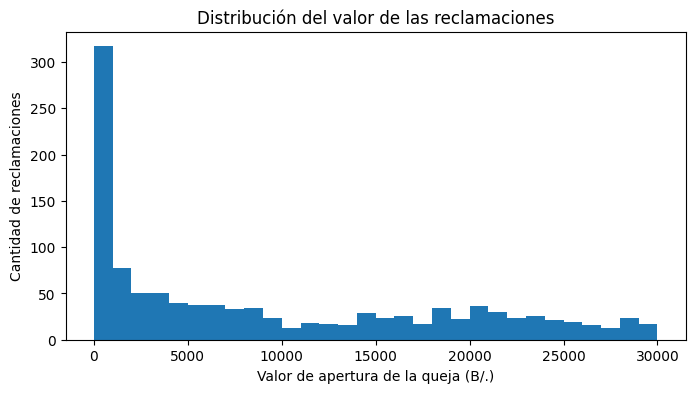

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.hist(
    df_modelo["Velor de Apertura de Queja"],
    bins=30
)

plt.title("Distribución del valor de las reclamaciones")
plt.xlabel("Valor de apertura de la queja (B/.)")
plt.ylabel("Cantidad de reclamaciones")

plt.show()

In [54]:
asimetria = df_modelo["Velor de Apertura de Queja"].skew()

print("Asimetría:", asimetria)

Asimetría: 0.6657697015411983


La distribución presenta asimetría positiva, lo que indica que existen algunas reclamaciones con montos considerablemente superiores al resto.

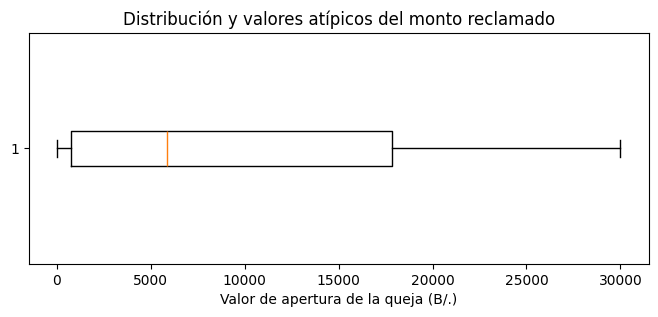

In [55]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df_modelo["Velor de Apertura de Queja"],
    vert=False
)

plt.title("Distribución y valores atípicos del monto reclamado")
plt.xlabel("Valor de apertura de la queja (B/.)")

plt.show()

# 8. Variable objetivo: Nivel de Riesgo (Bajo / Medio / Alto) Diseñar reglas de puntuacion

## 8.1 clasificar los motivos de queja por nivel de impacto

In [56]:
riesgo_motivo = {
    "Falta de información": 0,

    "Venta engañosa": 1,
    "Incumplimiento de servicio": 1,
    "Incumplimiento de contrato": 1,
    "Custodia de bien": 1,
    "Cobro indebido": 1,
    "Veracidad de la publicidad": 1,

    "Incumplimiento de garantía": 2,
    "Devolución de dinero": 2,
    "Daños y perjuicios": 2,
    "Mercancía defectuosa": 2,
    "Vicio oculto": 2
}



*  0 = impacto bajo
*  1 = impacto medio
*  2 = impacto alto




## 8.2 Asignar puntuación según Resultado de Queja

In [57]:
riesgo_resultado = {
    # 0 puntos - favorable
    "Acuerdo en audiencia/Devolución de dinero": 0,
    "Acuerdo en audiencia/Reparación": 0,
    "Acuerdo en audiencia/Aclaración": 0,
    "Acuerdo en audiencia/Varios": 0,
    "Ordena corrección": 0,

    # 1 punto - pendiente o sin resolución definitiva
    "En proceso": 1,
    "Pendiente constancia desistimiento": 1,
    "Desistimiento": 1,
    "Desistimiento/Devolución": 1,
    "Transacción extrajudicial": 1,
    "Abandono": 1,

    # 2 puntos - escalado o desfavorable
    "Ministerio Público": 2,
    "Corregiduría/Casa de Justicia Comunitaria de Paz": 2,
    "Inadmitida": 2,
    "Inhibe": 2,
    "Caducidad de la instancia": 2,
    "Resolución no acceder": 2
}

In [58]:
df_modelo["Puntos_Resultado"] = df_modelo["Resultado de Queja"].map(riesgo_resultado)

¿Hay algún Resultado de Queja al que olvidamos asignarle puntos?:

In [59]:
df_modelo.loc[
    df_modelo["Puntos_Resultado"].isna(),
    "Resultado de Queja"
].value_counts()

,count
Resultado de Queja,


In [60]:
df_modelo[
    ["Resultado de Queja", "Puntos_Resultado"]
].head(20)

,Resultado de Queja,Puntos_Resultado
0,En proceso,1
7,Desistimiento,1
9,Desistimiento,1
11,Desistimiento,1
12,En proceso,1
17,En proceso,1
18,Desistimiento,1
21,En proceso,1
22,En proceso,1
27,Desistimiento,1


## 8.3: asignar puntos según el monto reclamado

In [61]:
q1 = df_modelo["Velor de Apertura de Queja"].quantile(0.25)
q3 = df_modelo["Velor de Apertura de Queja"].quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)

def puntuar_monto(valor):
    if valor <= q1:
        return 0
    elif valor <= q3:
        return 1
    else:
        return 2

df_modelo["Puntos_Monto"] = (
    df_modelo["Velor de Apertura de Queja"]
    .apply(puntuar_monto)
)

Q1: 770.22
Q3: 17850.0


# puntuación queda automáticamente ligada a los datos.

In [62]:
df_modelo[
    ["Velor de Apertura de Queja", "Puntos_Monto"]
].head(20)

,Velor de Apertura de Queja,Puntos_Monto
0,3000.00,1
7,18500.00,2
9,7700.00,1
11,14490.00,1
12,8095.00,1
17,5220.00,1
18,500.00,0
21,2824.34,1
22,91.40,0
27,69.83,0


In [63]:
df_modelo["Puntos_Motivo"] = df_modelo["Motivo de Queja"].map(riesgo_motivo)

In [64]:
df_modelo[
    ["Motivo de Queja", "Puntos_Motivo"]
].head(20)

,Motivo de Queja,Puntos_Motivo
0,Incumplimiento de garantía,2
7,Incumplimiento de garantía,2
9,Incumplimiento de garantía,2
11,Incumplimiento de garantía,2
12,Incumplimiento de garantía,2
17,Incumplimiento de garantía,2
18,Falta de información,0
21,Incumplimiento de servicio,1
22,Falta de información,0
27,Incumplimiento de garantía,2


In [65]:
df_modelo["Puntaje_Total"] = (
    df_modelo["Puntos_Motivo"] +
    df_modelo["Puntos_Resultado"] +
    df_modelo["Puntos_Monto"]
)

In [66]:
df_modelo[
    [
        "Motivo de Queja",
        "Puntos_Motivo",
        "Resultado de Queja",
        "Puntos_Resultado",
        "Velor de Apertura de Queja",
        "Puntos_Monto",
        "Puntaje_Total"
    ]
].head(20)

,Motivo de Queja,Puntos_Motivo,Resultado de Queja,Puntos_Resultado,Velor de Apertura de Queja,Puntos_Monto,Puntaje_Total
0,Incumplimiento de garantía,2,En proceso,1,3000.00,1,4
7,Incumplimiento de garantía,2,Desistimiento,1,18500.00,2,5
9,Incumplimiento de garantía,2,Desistimiento,1,7700.00,1,4
11,Incumplimiento de garantía,2,Desistimiento,1,14490.00,1,4
12,Incumplimiento de garantía,2,En proceso,1,8095.00,1,4
17,Incumplimiento de garantía,2,En proceso,1,5220.00,1,4
18,Falta de información,0,Desistimiento,1,500.00,0,1
21,Incumplimiento de servicio,1,En proceso,1,2824.34,1,3
22,Falta de información,0,En proceso,1,91.40,0,1
27,Incumplimiento de garantía,2,Desistimiento,1,69.83,0,3


In [67]:
def clasificar_riesgo(puntaje):
    if puntaje <= 2:
        return "Bajo"
    elif puntaje <= 4:
        return "Medio"
    else:
        return "Alto"

df_modelo["Nivel_Riesgo"] = df_modelo["Puntaje_Total"].apply(clasificar_riesgo)

In [68]:
df_modelo["Nivel_Riesgo"].value_counts()

,count
Nivel_Riesgo,
Medio,648
Alto,265
Bajo,228


In [69]:
df_modelo.groupby("Nivel_Riesgo")["Velor de Apertura de Queja"].describe()

,count,mean,std,min,25%,50%,75%,max
Nivel_Riesgo,,,,,,,,
Alto,265.0,22848.190679,4356.037678,1175.13,20319.300,22795.0,25590.0000,30000.0
Bajo,228.0,1871.073728,2869.180815,0.00,197.215,500.0,2692.5375,16900.0
Medio,648.0,6513.456065,6409.417155,0.00,939.250,4500.0,10992.5000,29495.0


In [70]:
pd.crosstab(
    df_modelo["Nivel_Riesgo"],
    df_modelo["Motivo de Queja"]
)

Motivo de Queja,Cobro indebido,Custodia de bien,Daños y perjuicios,Devolución de dinero,Falta de información,Incumplimiento de contrato,Incumplimiento de garantía,Incumplimiento de servicio,Mercancía defectuosa,Venta engañosa,Veracidad de la publicidad,Vicio oculto
Nivel_Riesgo,,,,,,,,,,,,
Alto,0,0,0,0,0,0,260,0,0,0,0,5
Bajo,5,21,0,0,154,7,7,32,0,1,1,0
Medio,2,20,7,29,15,13,486,54,2,4,2,14


In [71]:
df_modelo["Marca de Producto"].drop_duplicates().sort_values().tolist()

['#\xadNULO!',
 'Acura',
 'Audi',
 'Ava',
 'BMW',
 'BMX',
 'Bestune',
 'Changan',
 'Cherry',
 'Chery QQ',
 'Chevrolet',
 'Chrysler',
 'DFSK',
 'Daihatsu',
 'Dodge',
 'Dongfeng',
 'Fiat',
 'Ford',
 'Forthing',
 'GAC',
 'GAP',
 'Geely',
 'Haval',
 'Honda',
 'Hyundai',
 'Infiniti',
 'Isuzu',
 'Izuzu',
 'JAC',
 'JEEP',
 'Jetour',
 'KIA',
 'KTM',
 'Kaiyi',
 'Kamura',
 'Karry',
 'Keeway',
 'Land Rover',
 'Lexus',
 'MG',
 'Maxus',
 'Mazda',
 'Mercedez Benz',
 'Mini Cooper',
 'Mitsubishi',
 'Nissan',
 'No registrado',
 'No se Registro',
 'Omoda',
 'POER',
 'Panasonic',
 'Peugeot',
 'Porsche',
 'RAM',
 'Renault',
 'Subaru',
 'Suzuki',
 'Tasco',
 'Tesla',
 'Toyota',
 'VGV',
 'Volkswagen',
 'Volvo',
 'Yamaha',
 'Yema']

In [72]:
df_modelo.loc[
    df_modelo["Marca de Producto"] == "Panasonic",
    ["Actividad", "Marca de Producto", "Producto", "Motivo de Queja"]
]

,Actividad,Marca de Producto,Producto,Motivo de Queja
5875,Agencia de autos,Panasonic,Batería de auto,Incumplimiento de garantía


In [73]:
df_modelo[
    ["Actividad", "Marca de Producto", "Producto"]
].sort_values(["Marca de Producto", "Actividad"])

,Actividad,Marca de Producto,Producto
3940,Repuestos para autos,#­NULO!,#­NULO!
5903,Venta de autos usados,Acura,Automóvil
629,Repuestos para autos,Audi,Auto
5372,Repuestos para autos,Audi,Automóvil
5535,Taller de reparación de autos,Audi,Automóvil
...,...,...,...
5379,Taller de reparación de autos,Volvo,Automóvil
9,Venta de autos usados,Volvo,Auto
5389,Venta de autos usados,Volvo,Amortiguadores
5698,Taller de reparación de autos,Yamaha,Moto


In [74]:
df_marcas_autos = df_modelo[
    df_modelo["Producto"].isin(["Auto", "Automóvil"])
].copy()

In [75]:
df_modelo[
    [
        "Marca de Producto",
        "Producto",
        "Motivo de Queja",
        "Puntos_Motivo",
        "Resultado de Queja",
        "Puntos_Resultado",
        "Velor de Apertura de Queja",
        "Puntos_Monto",
        "Puntaje_Total",
        "Nivel_Riesgo"
    ]
]

,Marca de Producto,Producto,Motivo de Queja,Puntos_Motivo,Resultado de Queja,Puntos_Resultado,Velor de Apertura de Queja,Puntos_Monto,Puntaje_Total,Nivel_Riesgo
0,KIA,Auto,Incumplimiento de garantía,2,En proceso,1,3000.0,1,4,Medio
7,Hyundai,Auto,Incumplimiento de garantía,2,Desistimiento,1,18500.0,2,5,Alto
9,Volvo,Auto,Incumplimiento de garantía,2,Desistimiento,1,7700.0,1,4,Medio
11,Suzuki,Auto,Incumplimiento de garantía,2,Desistimiento,1,14490.0,1,4,Medio
12,No se Registro,No se Registro,Incumplimiento de garantía,2,En proceso,1,8095.0,1,4,Medio
...,...,...,...,...,...,...,...,...,...,...
6616,Kaiyi,Automóvil,Incumplimiento de garantía,2,En proceso,1,26739.3,2,5,Alto
6617,Hyundai,Automóvil,Incumplimiento de garantía,2,En proceso,1,5100.0,1,4,Medio
6720,GAC,Automóvil,Incumplimiento de servicio,1,En proceso,1,24950.0,2,4,Medio
6721,No se Registro,Pieza de Repuesto,Custodia de bien,1,En proceso,1,353.0,0,2,Bajo


In [76]:
pd.set_option("display.max_rows", None)

In [77]:
df_sin_marca = df_modelo[
    ~df_modelo["Marca de Producto"].isin(["No se Registro", "No registrado"])
]

len(df_sin_marca)

974

In [78]:
print("Total actual:", len(df_modelo))
print("Sin marca registrada:", len(df_modelo) - len(df_sin_marca))
print("Registros restantes:", len(df_sin_marca))

Total actual: 1141
Sin marca registrada: 167
Registros restantes: 974


# 9. limpiar marcas de productos que aparecen "No se registro"

In [79]:
df_sin_marca["Marca de Producto"].value_counts()

,count
Marca de Producto,
Hyundai,143
Toyota,135
KIA,121
Nissan,100
Chevrolet,69
Suzuki,44
Honda,42
Ford,31
Mitsubishi,29


In [80]:
marcas_descartar = [
    "Yema",
    "#­NULO!",
    "Panasonic",
    "Ava",
    "KTM",
    "Keeway",
    "Yamaha"
]

df_sin_marca = df_sin_marca[
    ~df_sin_marca["Marca de Producto"].isin(marcas_descartar)
]

In [81]:
print("Registros después de descartar marcas:", len(df_sin_marca))

Registros después de descartar marcas: 965


Se descartaron registros correspondientes a marcas con una sola aparición, valores inválidos y marcas asociadas a motocicletas, ya que no forman parte del alcance principal del análisis y su eliminación no representa un impacto significativo sobre el total de registros.

In [82]:
reemplazos_marcas = {
    "Cherry": "Chery",
    "Mercedez Benz": "Mercedes-Benz",
    "BMX": "BMW",
    "Chery QQ": "Chery",
    "Mini Cooper": "MINI",
    "Izuzu": "Isuzu"
}
df_sin_marca["Marca de Producto"] = (
    df_sin_marca["Marca de Producto"]
    .replace(reemplazos_marcas)
)

In [83]:
df_sin_marca["Marca de Producto"].value_counts()

,count
Marca de Producto,
Hyundai,143
Toyota,135
KIA,121
Nissan,100
Chevrolet,69
Suzuki,44
Honda,42
Ford,31
Mitsubishi,29


In [84]:
marcas_pocas = df_sin_marca["Marca de Producto"].value_counts()

marcas_pocas[marcas_pocas <= 3]

,count
Marca de Producto,
Infiniti,3
Subaru,3
Karry,3
Porsche,3
MINI,3
Omoda,2
JAC,2
VGV,2
Tasco,2


In [85]:
marcas_revisar = ["Tasco", "GAP", "Kamura", "POER", "Karry"]

df_sin_marca[
    df_sin_marca["Marca de Producto"].isin(marcas_revisar)
][
    ["Marca de Producto", "Producto", "Actividad", "Motivo de Queja"]
]

,Marca de Producto,Producto,Actividad,Motivo de Queja
2517,Tasco,Batería de auto,Repuestos para autos,Incumplimiento de garantía
2789,GAP,Auto,Agencia de autos,Incumplimiento de garantía
3335,Kamura,Auto,Venta de autos usados,Incumplimiento de garantía
3791,POER,Auto,Agencia de autos,Incumplimiento de garantía
4123,Karry,Auto,Agencia de autos,Incumplimiento de garantía
4448,Tasco,Batería de auto,Repuestos para autos,Mercancía defectuosa
5543,Karry,Automóvil,Agencia de autos,Incumplimiento de garantía
5881,Karry,Automóvil,Agencia de autos,Incumplimiento de garantía


In [86]:
df_sin_marca = df_sin_marca[
    df_sin_marca["Marca de Producto"] != "Tasco"
]

print("Registros restantes:", len(df_sin_marca))

Registros restantes: 963


Se eliminaron los registros correspondientes a Tasco, debido a que están asociados a baterías y repuestos para autos, y no representan una marca de vehículo dentro del alcance del análisis.

In [87]:
df_final = df_sin_marca.copy()

print("Registros finales:", len(df_final))
print("Marcas diferentes:", df_final["Marca de Producto"].nunique())

Registros finales: 963
Marcas diferentes: 52


In [88]:
df_final.isna().sum()

,0
Fecha de Entrada de Queja,0
Año Recibido de Queja,0
Agente Económico,0
Actividad,0
Marca de Producto,0
Producto,0
Motivo de Queja,0
Velor de Apertura de Queja,0
Resultado de Queja,0
Puntos_Resultado,0


In [89]:
df_final.duplicated().sum()

np.int64(0)

# 10. Índice relativo de riesgo por marca

Hasta este punto, `Nivel_Riesgo` clasifica **cada reclamación** como Bajo, Medio o Alto.

Ahora calcularemos un **índice relativo de riesgo por marca**. Este índice permitirá comparar la proporción de reclamaciones de riesgo Alto de cada marca con la proporción de reclamaciones de riesgo Alto de todo el conjunto analizado.

La fórmula es:

**Índice relativo = % de reclamaciones de riesgo Alto de la marca / % de reclamaciones de riesgo Alto del conjunto total**

Interpretación:

- **Índice = 1:** la marca tiene una proporción de reclamaciones de riesgo Alto similar al conjunto general.
- **Índice > 1:** la marca tiene una proporción de reclamaciones de riesgo Alto superior al conjunto general.
- **Índice < 1:** la marca tiene una proporción de reclamaciones de riesgo Alto inferior al conjunto general.

Este indicador es **relativo a las reclamaciones de ACODECO** y no a la cantidad de vehículos vendidos.


## 10.1 Proporción general de reclamaciones de riesgo Alto

In [90]:
# Proporción de reclamaciones clasificadas como riesgo Alto
proporcion_alto_general = (
    df_final["Nivel_Riesgo"].eq("Alto").mean()
)

print(
    "Porcentaje general de reclamaciones de riesgo Alto:",
    round(proporcion_alto_general * 100, 2),
    "%"
)


Porcentaje general de reclamaciones de riesgo Alto: 25.55 %


## 10.2 Calcular el índice relativo de riesgo por marca

In [91]:
# Resumen de reclamaciones por marca
riesgo_marca = (
    df_final
    .groupby("Marca de Producto")
    .agg(
        Total_Reclamaciones=("Nivel_Riesgo", "size"),
        Reclamaciones_Alto=("Nivel_Riesgo", lambda x: (x == "Alto").sum())
    )
    .reset_index()
)

# Porcentaje de reclamaciones de riesgo Alto dentro de cada marca
riesgo_marca["Porcentaje_Alto"] = (
    riesgo_marca["Reclamaciones_Alto"]
    / riesgo_marca["Total_Reclamaciones"]
    * 100
)

# Índice relativo respecto al comportamiento general del dataset
riesgo_marca["Indice_Relativo_Riesgo"] = (
    (riesgo_marca["Porcentaje_Alto"] / 100)
    / proporcion_alto_general
)

riesgo_marca = riesgo_marca.sort_values(
    "Indice_Relativo_Riesgo",
    ascending=False
)

riesgo_marca.head(20)


,Marca de Producto,Total_Reclamaciones,Reclamaciones_Alto,Porcentaje_Alto,Indice_Relativo_Riesgo
3,Bestune,1,1,100.000000,3.914634
14,Forthing,5,5,100.000000,3.914634
18,Haval,1,1,100.000000,3.914634
16,GAP,1,1,100.000000,3.914634
39,Omoda,2,2,100.000000,3.914634
40,POER,1,1,100.000000,3.914634
43,RAM,1,1,100.000000,3.914634
49,VGV,2,2,100.000000,3.914634
25,Jetour,15,15,100.000000,3.914634
23,JAC,2,2,100.000000,3.914634


## 10.3 Interpretación del índice

In [92]:
def interpretar_indice(indice):
    if indice > 1:
        return "Por encima del promedio"
    elif indice < 1:
        return "Por debajo del promedio"
    else:
        return "Igual al promedio"

riesgo_marca["Interpretacion"] = (
    riesgo_marca["Indice_Relativo_Riesgo"]
    .apply(interpretar_indice)
)

riesgo_marca[
    [
        "Marca de Producto",
        "Total_Reclamaciones",
        "Reclamaciones_Alto",
        "Porcentaje_Alto",
        "Indice_Relativo_Riesgo",
        "Interpretacion"
    ]
].head(20)


,Marca de Producto,Total_Reclamaciones,Reclamaciones_Alto,Porcentaje_Alto,Indice_Relativo_Riesgo,Interpretacion
3,Bestune,1,1,100.000000,3.914634,Por encima del promedio
14,Forthing,5,5,100.000000,3.914634,Por encima del promedio
18,Haval,1,1,100.000000,3.914634,Por encima del promedio
16,GAP,1,1,100.000000,3.914634,Por encima del promedio
39,Omoda,2,2,100.000000,3.914634,Por encima del promedio
40,POER,1,1,100.000000,3.914634,Por encima del promedio
43,RAM,1,1,100.000000,3.914634,Por encima del promedio
49,VGV,2,2,100.000000,3.914634,Por encima del promedio
25,Jetour,15,15,100.000000,3.914634,Por encima del promedio
23,JAC,2,2,100.000000,3.914634,Por encima del promedio


### Cómo leer el resultado

Por ejemplo, si una marca obtiene un índice de **1.50**, significa que, **dentro de las reclamaciones registradas en ACODECO**, su proporción de casos clasificados como riesgo Alto es 1.5 veces la proporción general.

No significa que sus vehículos sean 1.5 veces más propensos a presentar problemas, porque para afirmar eso necesitaríamos conocer cuántos vehículos de esa marca circulan o se vendieron.


## 10.4 Evitar conclusiones engañosas por marcas con muy pocos casos

Una marca con solo una o dos reclamaciones puede obtener un índice muy alto aunque exista muy poca información. Por eso conviene observar el índice junto con `Total_Reclamaciones`.

La siguiente vista muestra únicamente marcas con **5 o más reclamaciones** como apoyo para la interpretación descriptiva. El dataset original no se elimina ni se modifica.


In [93]:
riesgo_marca_5omas = riesgo_marca[
    riesgo_marca["Total_Reclamaciones"] >= 5
].copy()

riesgo_marca_5omas[
    [
        "Marca de Producto",
        "Total_Reclamaciones",
        "Reclamaciones_Alto",
        "Porcentaje_Alto",
        "Indice_Relativo_Riesgo",
        "Interpretacion"
    ]
].head(20)


,Marca de Producto,Total_Reclamaciones,Reclamaciones_Alto,Porcentaje_Alto,Indice_Relativo_Riesgo,Interpretacion
14,Forthing,5,5,100.000000,3.914634,Por encima del promedio
25,Jetour,15,15,100.000000,3.914634,Por encima del promedio
17,Geely,9,7,77.777778,3.044715,Por encima del promedio
27,Kaiyi,8,6,75.000000,2.935976,Por encima del promedio
24,JEEP,6,4,66.666667,2.609756,Por encima del promedio
15,GAC,16,10,62.500000,2.446646,Por encima del promedio
32,MG,13,8,61.538462,2.409006,Por encima del promedio
11,Dongfeng,5,3,60.000000,2.348780,Por encima del promedio
50,Volkswagen,7,4,57.142857,2.236934,Por encima del promedio
22,Isuzu,8,4,50.000000,1.957317,Por encima del promedio


## 10.5 Visualización del índice relativo de riesgo

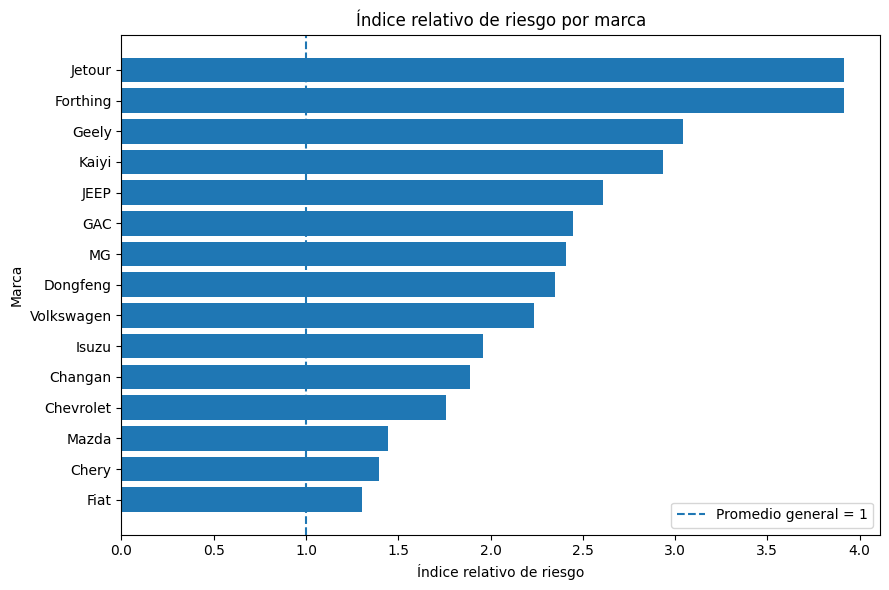

In [94]:
import matplotlib.pyplot as plt

top_indice = (
    riesgo_marca_5omas
    .sort_values("Indice_Relativo_Riesgo", ascending=False)
    .head(15)
    .sort_values("Indice_Relativo_Riesgo")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_indice["Marca de Producto"],
    top_indice["Indice_Relativo_Riesgo"]
)

plt.axvline(
    1,
    linestyle="--",
    label="Promedio general = 1"
)

plt.title("Índice relativo de riesgo por marca")
plt.xlabel("Índice relativo de riesgo")
plt.ylabel("Marca")
plt.legend()
plt.tight_layout()
plt.show()
